In [13]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import json, numpy as np, pandas as pd, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [14]:
df_beyondblue = pd.read_csv('beyondblue_severity.csv')
df_beyondblue.head()

,Unnamed: 0,keyword,post_content_preview,thread_url,post_date,comments,num_comments,post_content_preview_clean,comments_clean,post_length,...,vader_neu,vader_pos,vader_compound,vader_sentiment,tb_polarity,tb_subjectivity,tb_sentiment,otsu_class,jenks_class,gmm_class
0,0,anxiety,Hi my name is Michelle and I have hadAnxietymy...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎23-05-2025,"[""Dear Michelle ~Welcome here to the Support F...",2,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety coped ...,200,...,0.695,0.139,-0.1280,negative,-0.066667,0.608333,negative,neutral,neutral,neutral
1,1,anxiety,"Hi, I’ve suffered on and off fromanxietyover...",https://forums.beyondblue.org.au/t5/welcome-an...,‎28-05-2025,['Hello new member and welcome to the forum.Pl...,4,suffered fromanxietyover life recent years rea...,new member welcome forumplease arrived place n...,173,...,0.572,0.000,-0.7178,negative,-0.250000,0.625000,negative,negative,negative,negative
2,2,anxiety,"I have had chronicanxietysince 2016, but I hav...",https://forums.beyondblue.org.au/t5/anxiety/an...,‎06-01-2025,"['Dear Guest-65543263,I can very much relate t...",9,chronicanxietysince managed bay medicationexer...,dear guest relate written perimenopause sympto...,186,...,1.000,0.000,0.0000,neutral,0.250000,0.250000,positive,neutral,neutral,neutral
3,3,anxiety,Hello I struggle with very badanxietyand panic...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-03-2025,"['Hello any advice please would help', ""Hi don...",4,struggle badanxietyand panic attacks finally g...,advice ashamed struggle tell struggling helps ...,197,...,0.216,0.418,0.2960,positive,0.633333,0.633333,positive,positive,positive,positive
4,4,anxiety,I’ve recently sold my mortgage free home that ...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-06-2025,"[""Hi KCT welcomeAnxiety is a serious condition...",3,recently sold mortgage free home lived years c...,kct welcomeanxiety condition underestimated po...,192,...,0.578,0.284,0.5106,positive,-0.013333,0.423333,neutral,positive,positive,positive


In [15]:

MODEL_NAME = "SamLowe/roberta-base-go_emotions"
# prefer Apple MPS when available, otherwise CUDA, otherwise CPU
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
id2label  = model.config.id2label
labels_order = [id2label[i] for i in range(len(id2label))]

@torch.no_grad()
def goemotion_scores(texts, batch_size=16, max_length=256):
    probs = []
    model.eval()
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        p = torch.sigmoid(model(**enc).logits).detach().cpu().numpy()
        probs.append(p)
    return np.vstack(probs)

def apply_goemotions(df, text_col="text_clean", threshold=0.30, prefix="goe_"):
    texts = df[text_col].fillna("").astype(str).tolist()
    P = goemotion_scores(texts)

    # per-emotion columns
    for j, lab in enumerate(labels_order):
        df[f"{prefix}{lab}_prob"] = P[:, j].astype("float32")
        df[f"{prefix}{lab}"]      = (P[:, j] >= threshold).astype("int8")

    # ---- FIXED TOP-3 (use row[j], not 'p') ----
    top3_list = []
    for row in P:                      # row is a 1D numpy array of probs
        idx = np.argsort(-row)[:3]     # top-3 indices
        top3 = [(labels_order[j], float(row[j])) for j in idx]
        top3_list.append(json.dumps(top3))
    df[f"{prefix}top3"] = top3_list

    # dominant, any_positive, sum_active
    df[f"{prefix}dominant"]    = [labels_order[i] for i in P.argmax(axis=1)]
    df[f"{prefix}any_positive"] = (P.max(axis=1) >= threshold).astype("int8")
    df[f"{prefix}sum_active"]   = (P >= threshold).sum(axis=1).astype("int16")
    return df
df_beyondblue = apply_goemotions(df_beyondblue, text_col="post_text_lemmas", threshold=0.30, prefix="goe_")

In [16]:
# ==========================================
# GoEmotions → Ekman groups (no thresholds, no 0/1)
# Adds:
#   goe_ekman_<group>_prob  (mean of member probs)
#   goe_ekman_top3          (JSON of top-3 groups with probs)
#   goe_ekman_dominant      (argmax group name)
# ==========================================
import numpy as np
import json

# your mapping
ekman_map = {
    "anger":   ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear":    ["fear", "nervousness"],
    "joy":     ["amusement","excitement","joy","love","desire","optimism",
                "caring","pride","admiration","gratitude","relief","approval"],
    "sadness": ["sadness","disappointment","embarrassment","grief","remorse"],
    "surprise":["surprise","realization","curiosity"],
    "neutral": ["neutral"]
}

PREFIX = "goe_"  # keep your existing prefix

# sanity check
prob_cols = [c for c in df_beyondblue.columns if c.startswith(PREFIX) and c.endswith("_prob")]
if not prob_cols:
    raise RuntimeError(f"No GoEmotions probability columns found with prefix '{PREFIX}'. Run your apply_goemotions first.")

# compute mean prob per Ekman group
ekman_groups = list(ekman_map.keys())
for g in ekman_groups:
    cols = [f"{PREFIX}{e}_prob" for e in ekman_map[g] if f"{PREFIX}{e}_prob" in df_beyondblue.columns]
    if cols:
        df_beyondblue[f"{PREFIX}ekman_{g}_prob"] = df_beyondblue[cols].mean(axis=1).astype("float32")
    else:
        # if somehow no member columns are present, set 0.0
        df_beyondblue[f"{PREFIX}ekman_{g}_prob"] = 0.0

# build matrix for top3/dominant (no thresholding)
ekman_prob_cols = [f"{PREFIX}ekman_{g}_prob" for g in ekman_groups]
M = df_beyondblue[ekman_prob_cols].to_numpy(float)  # (N, 7)

top3_json = []
dominant = []
for row in M:
    idx = np.argsort(-row)[:3]
    triples = [(ekman_groups[j], float(row[j])) for j in idx]
    top3_json.append(json.dumps(triples))
    dominant.append(ekman_groups[int(np.argmax(row))])

df_beyondblue[f"{PREFIX}ekman_top3"]     = top3_json
df_beyondblue[f"{PREFIX}ekman_dominant"] = dominant

# quick peek
show_cols = [f"{PREFIX}ekman_dominant", f"{PREFIX}ekman_top3"] + ekman_prob_cols
print(df_beyondblue[show_cols].head(5))


  goe_ekman_dominant                                     goe_ekman_top3  \
0               fear  [["fear", 0.2784978747367859], ["neutral", 0.0...   
1               fear  [["fear", 0.22359919548034668], ["sadness", 0....   
2            neutral  [["neutral", 0.9119173288345337], ["fear", 0.0...   
3               fear  [["fear", 0.37048792839050293], ["neutral", 0....   
4            neutral  [["neutral", 0.7377844452857971], ["sadness", ...   

   goe_ekman_anger_prob  goe_ekman_disgust_prob  goe_ekman_fear_prob  \
0              0.009054                0.007664             0.278498   
1              0.006025                0.002521             0.223599   
2              0.003594                0.003397             0.015084   
3              0.006177                0.003840             0.370488   
4              0.002832                0.004036             0.024528   

   goe_ekman_joy_prob  goe_ekman_sadness_prob  goe_ekman_surprise_prob  \
0            0.008877                0.047

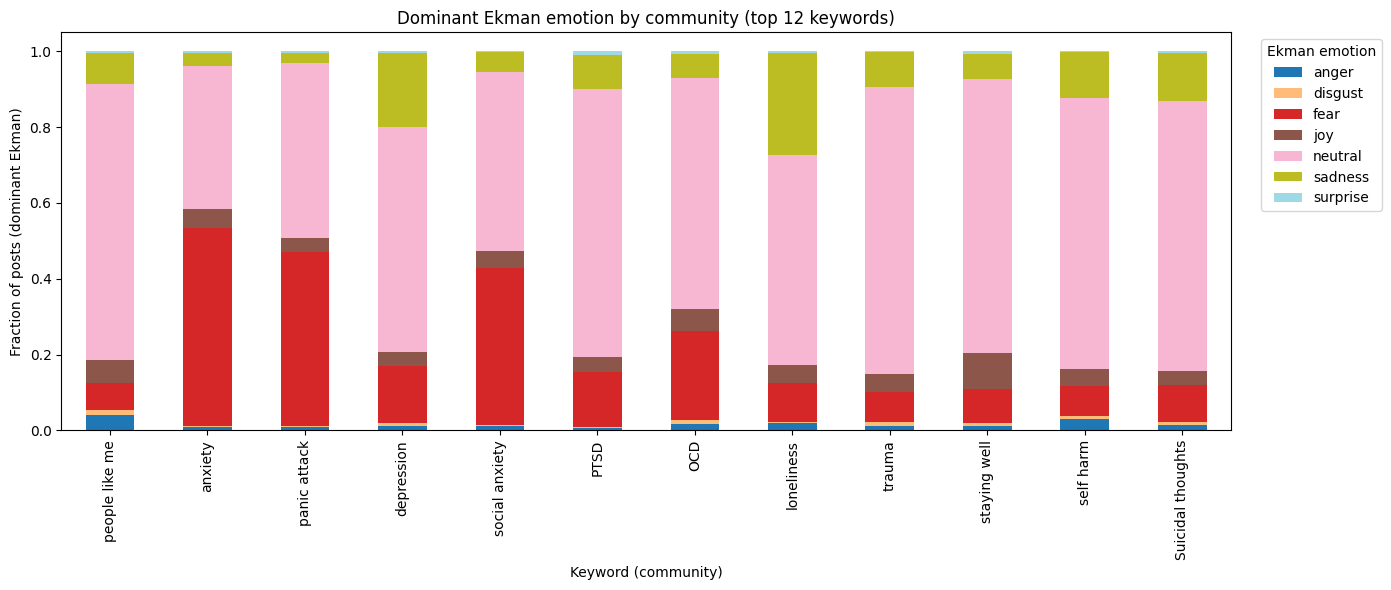

Top dominant emotion for each of the top communities:
keyword
people like me       neutral
anxiety                 fear
panic attack         neutral
depression           neutral
social anxiety       neutral
PTSD                 neutral
OCD                  neutral
loneliness           neutral
trauma               neutral
staying well         neutral
self harm            neutral
Suicidal thoughts    neutral
dtype: object

Emotion richness (GoEmotions active per post) summary:
                  count      mean       std  min  25%  50%  75%  max
goe_sum_active  18266.0  1.146064  0.458535  0.0  1.0  1.0  1.0  3.0


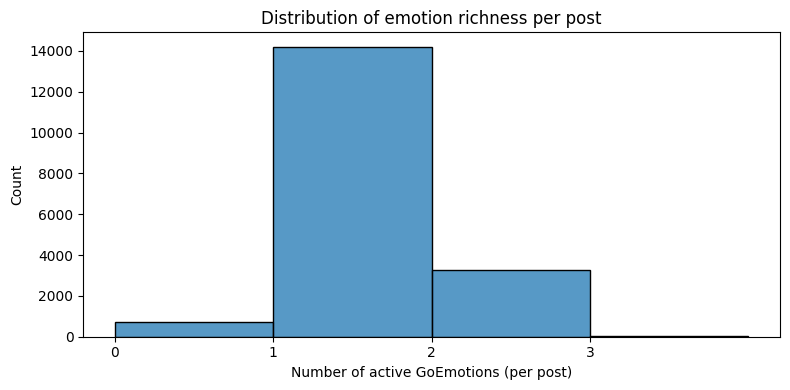


Pairwise co-activation (counts and P(B|A)) for anger/fear/sadness (threshold = 0.30):
                 and  A_total  P(B|A)
fear    sadness    0     2303     0.0
        anger      0     2303     0.0
sadness fear       0        0     NaN
        anger      0        0     NaN
anger   fear       0       83     0.0
        sadness    0       83     0.0

Triple co-activation counts (fear,sadness,anger) as (0/1):
   (fear,sadness,anger)  level_1  level_2  count
0                     0        0        0  15880
4                     1        0        0   2303
1                     0        0        1     83
2                     0        1        0      0
3                     0        1        1      0
5                     1        0        1      0
6                     1        1        0      0
7                     1        1        1      0


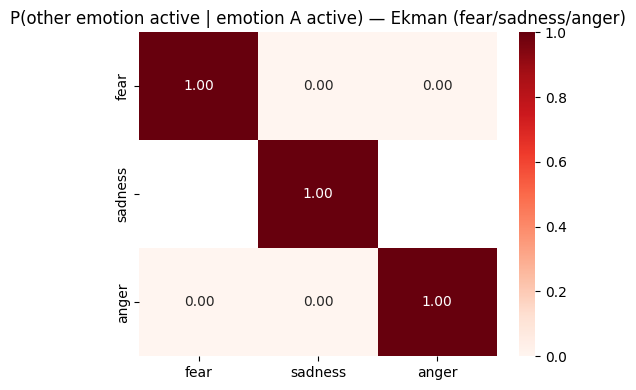

In [20]:
# Emotion / community / richness / co-activation analyses
# Assumes previous cells have run and variables like df_beyondblue, ekman_groups, ekman_prob_cols exist.

# PARAMETERS
TOP_K = 12                # how many keywords to show in stacked bar
THRESH = 0.30             # threshold for considering an Ekman group "active" in co-activation
EKMAN_PREFIX = "goe_ekman_"  # prefix used for ekman group prob columns
EKMAN_DOM_COL = f"{EKMAN_PREFIX}dominant"  # 'goe_ekman_dominant'

# Sanity checks
if "keyword" not in df_beyondblue.columns:
    raise RuntimeError("df_beyondblue has no 'keyword' column")

# 1) Emotion by subreddit (which emotions dominate which communities)
ct = pd.crosstab(df_beyondblue["keyword"], df_beyondblue[EKMAN_DOM_COL])
if ct.empty:
    print("No data for dominant Ekman emotions by keyword.")
else:
    top_keywords = df_beyondblue["keyword"].value_counts().nlargest(TOP_K).index.tolist()
    ct_top = ct.loc[top_keywords]
    ct_frac = ct_top.div(ct_top.sum(axis=1), axis=0)

    ax = ct_frac.plot(kind="bar", stacked=True, figsize=(14, 6), colormap="tab20")
    ax.set_ylabel("Fraction of posts (dominant Ekman)")
    ax.set_xlabel("Keyword (community)")
    ax.set_title(f"Dominant Ekman emotion by community (top {TOP_K} keywords)")
    ax.legend(title="Ekman emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # print top emotion per shown community
    top_emotions = ct_top.idxmax(axis=1)
    print("Top dominant emotion for each of the top communities:")
    print(top_emotions)

# 2) Emotion richness per post (how many GoEmotions active per post)
# apply_goemotions earlier created 'goe_sum_active' (counts of active GoEmotions per post)
if "goe_sum_active" in df_beyondblue.columns:
    richness = df_beyondblue["goe_sum_active"]
    print("\nEmotion richness (GoEmotions active per post) summary:")
    print(richness.describe().to_frame().T)
    plt.figure(figsize=(8,4))
    sns.histplot(richness, bins=range(0, int(richness.max())+2), kde=False)
    plt.xlabel("Number of active GoEmotions (per post)")
    plt.title("Distribution of emotion richness per post")
    plt.xticks(range(0, int(richness.max())+1))
    plt.tight_layout()
    plt.show()
else:
    print("Column 'goe_sum_active' not found — run apply_goemotions with threshold to create it.")

# 3) Emotion co-activation → how sadness/fear/anger appear together (Ekman groups)
target = ["fear", "sadness", "anger"]
missing = [g for g in target if f"{EKMAN_PREFIX}{g}_prob" not in df_beyondblue.columns]
if missing:
    raise RuntimeError(f"Missing Ekman prob cols for: {missing}. Run the Ekman mapping cell first.")

# binary active flags per Ekman group (using THRESH)
for g in target:
    col_bin = f"ek_{g}_active"
    df_beyondblue[col_bin] = (df_beyondblue[f"{EKMAN_PREFIX}{g}_prob"] >= THRESH).astype(int)

# pairwise co-occurrence counts and conditional probabilities P(B|A)
pairs = {}
for a in target:
    for b in target:
        if a == b:
            continue
        A = df_beyondblue[f"ek_{a}_active"] == 1
        B = df_beyondblue[f"ek_{b}_active"] == 1
        cnt_and = int((A & B).sum())
        cnt_a = int(A.sum())
        cond = cnt_and / cnt_a if cnt_a > 0 else float("nan")
        pairs[(a,b)] = {"and": cnt_and, "A_total": cnt_a, "P(B|A)": cond}

print("\nPairwise co-activation (counts and P(B|A)) for anger/fear/sadness (threshold = {:.2f}):".format(THRESH))
print(pd.DataFrame.from_dict(pairs, orient="index"))

# triple-pattern counts (2^3 combos)
combo_counts = {}
for fa in [0,1]:
    for sa in [0,1]:
        for aa in [0,1]:
            mask = (df_beyondblue["ek_fear_active"]==fa) & (df_beyondblue["ek_sadness_active"]==sa) & (df_beyondblue["ek_anger_active"]==aa)
            combo_counts[(fa,sa,aa)] = int(mask.sum())

combo_df = pd.Series(combo_counts).rename("count").reset_index().rename(columns={"level_0":"(fear,sadness,anger)"})
print("\nTriple co-activation counts (fear,sadness,anger) as (0/1):")
print(combo_df.sort_values("count", ascending=False).head(8))

# visualize pairwise conditional probability matrix P(j | i)
cond_mat = pd.DataFrame(index=target, columns=target, dtype=float)
for a in target:
    for b in target:
        if a == b:
            cond_mat.loc[a,b] = 1.0
        else:
            cond_mat.loc[a,b] = pairs[(a,b)]["P(B|A)"]

plt.figure(figsize=(5,4))
sns.heatmap(cond_mat.astype(float), annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.title("P(other emotion active | emotion A active) — Ekman (fear/sadness/anger)")
plt.tight_layout()
plt.show()

In [17]:
df_beyondblue['goe_ekman_dominant'].value_counts()

goe_ekman_dominant
neutral     11117
fear         3927
sadness      1829
joy           892
anger         295
disgust       115
surprise       91
Name: count, dtype: int64

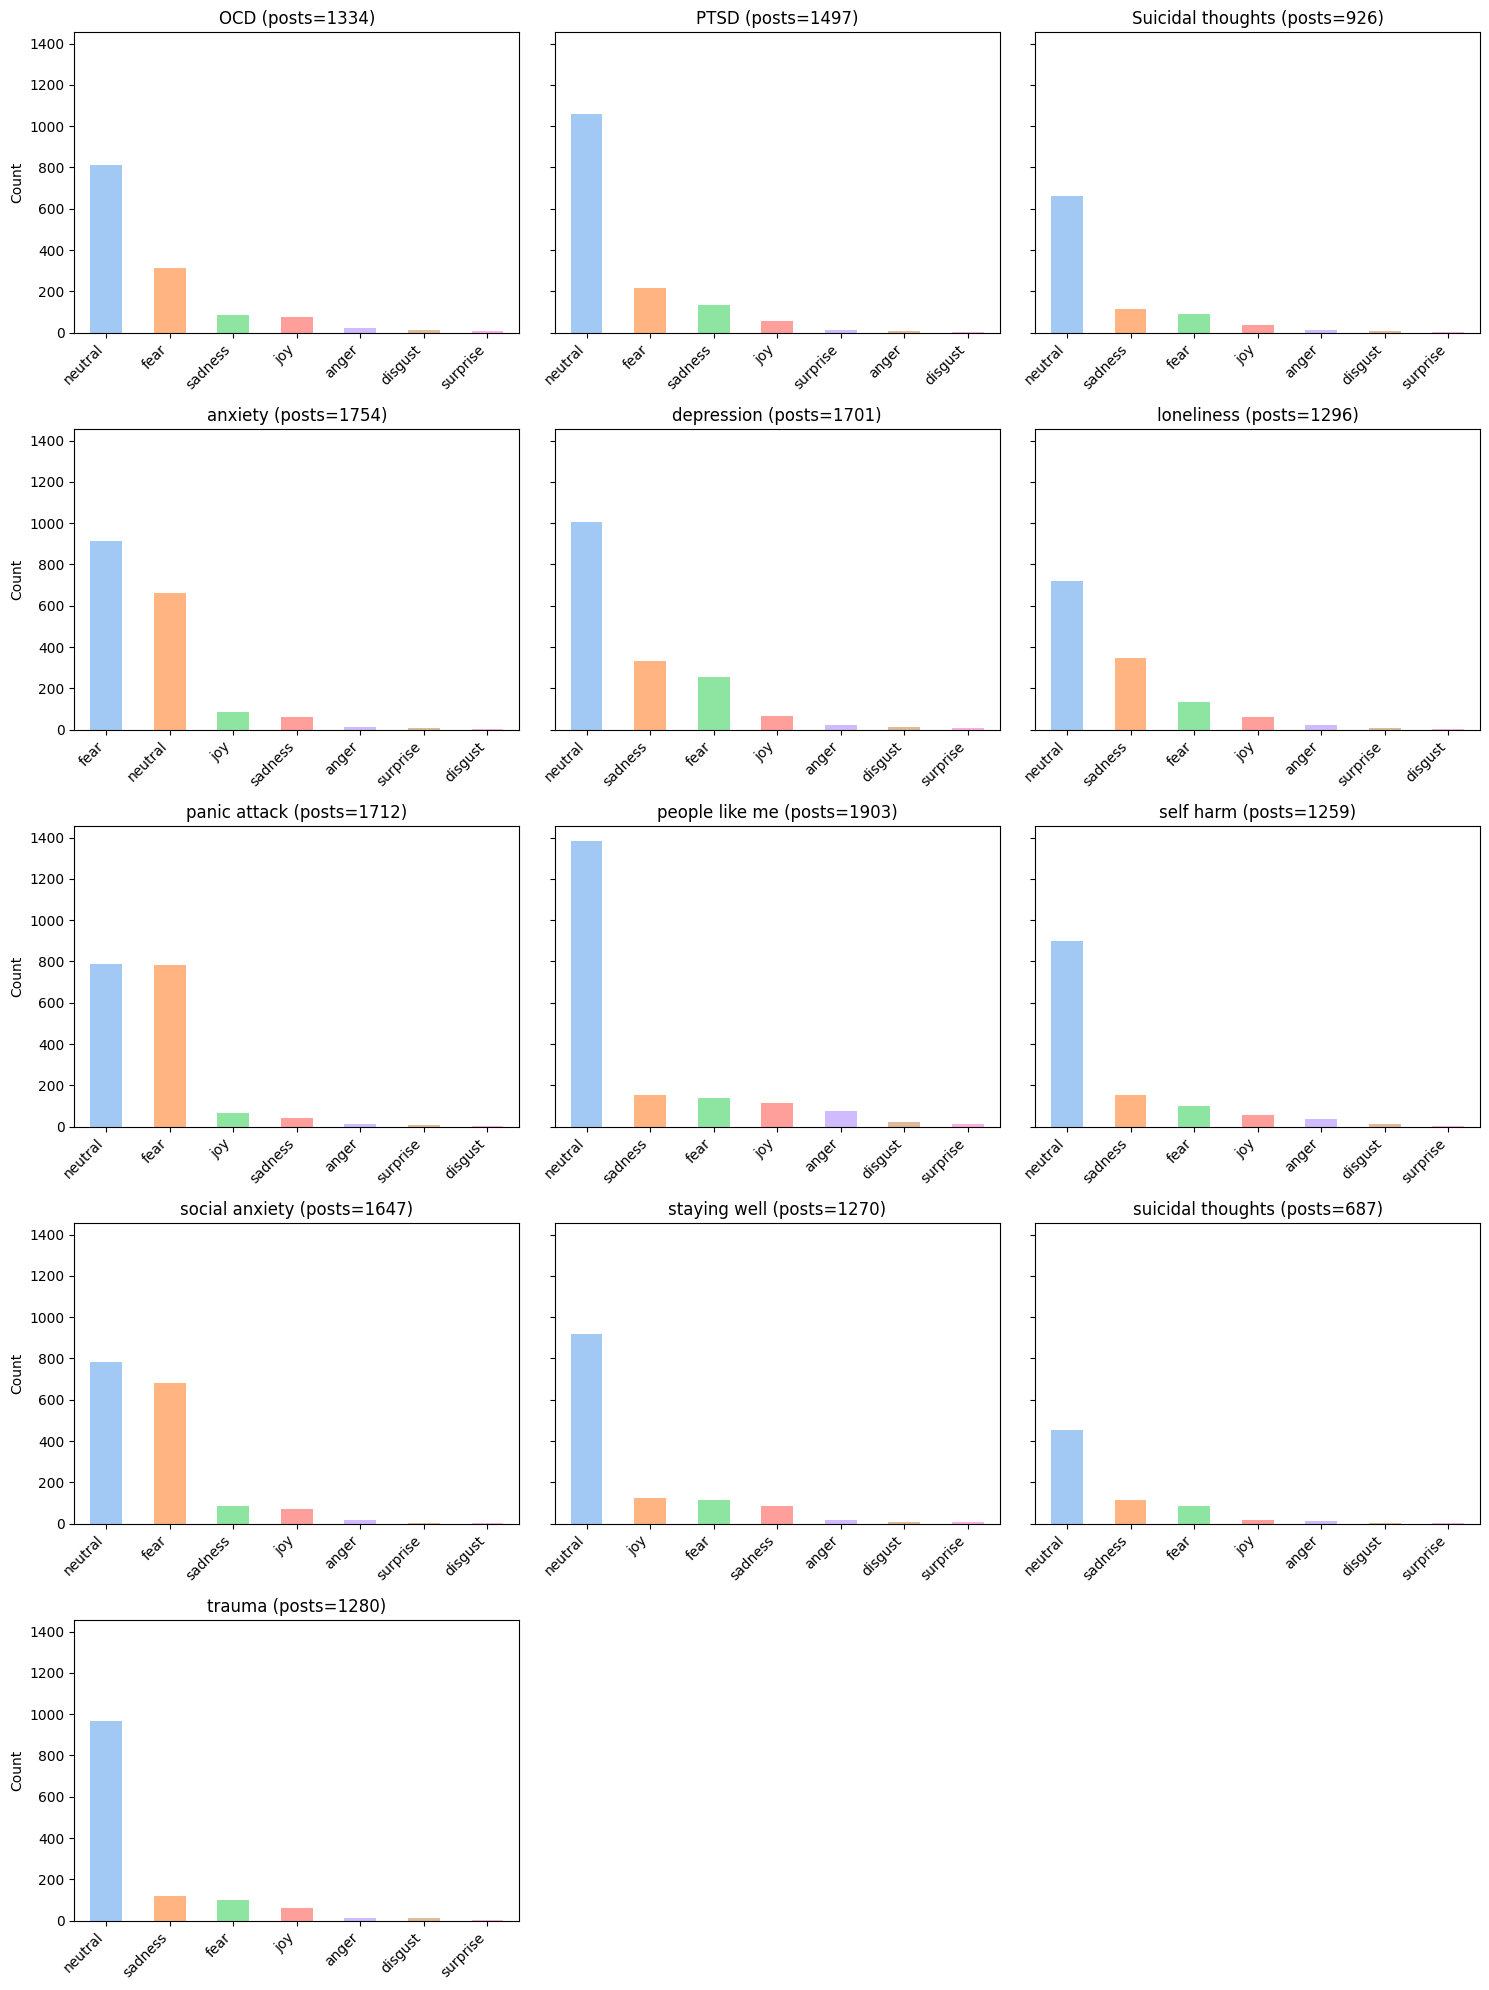

In [18]:
import math
import numpy as np

# Plot dominant GoEmotions distribution per beyondblue keyword
DF = df_beyondblue
emotion_col = 'goe_ekman_dominant'

if emotion_col not in DF.columns:
    raise RuntimeError(f"Column '{emotion_col}' not found in df_beyondblue. Run the GoEmotions → Ekman mapping cells first.")

# group and pivot
dominant_counts = DF.groupby(['keyword', emotion_col]).size().unstack(fill_value=0)

if dominant_counts.empty:
    print("No data to plot (dominant_counts empty).")
else:
    keywords = dominant_counts.index.tolist()
    n = len(keywords)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), sharey=True)
    axes = np.array(axes).ravel()

    for i, kw in enumerate(keywords):
        ax = axes[i]
        series = dominant_counts.loc[kw].sort_values(ascending=False)
        series.plot(kind='bar', ax=ax, color=sns.color_palette("pastel", n_colors=len(series)))
        ax.set_title(f'{kw} (posts={int(series.sum())})')
        ax.set_xlabel('')
        if i % ncols == 0:
            ax.set_ylabel('Count')
        else:
            ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # hide any extra axes
    for j in range(len(keywords), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [19]:
#convert to csv
df_beyondblue.to_csv('beyondblue_goemotions_ekman.csv', index=False)